In [2]:
# ═══════════════════════════════════════════════════════════════════
# SHAP MODEL EXPLAINABILITY
# By: Garvit Mittal
# ═══════════════════════════════════════════════════════════════════

!pip install shap --quiet

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
from google.colab import files

print("Upload required CSV files:")
print("Required: shipments.csv, shifts.csv, throughput_scans.csv, disruptions.csv, dock_events.csv")
uploaded = files.upload()

shipments    = pd.read_csv('shipments.csv')
shifts       = pd.read_csv('shifts.csv')
throughput   = pd.read_csv('throughput_scans.csv')
disruptions  = pd.read_csv('disruptions.csv')
dock_events  = pd.read_csv('dock_events.csv')

print(f"\n✅ Files loaded!")
print(f"   Shipments:   {len(shipments)} rows")
print(f"   Shifts:      {len(shifts)} rows")
print(f"   Throughput:  {len(throughput)} rows")
print(f"   Disruptions: {len(disruptions)} rows")
print(f"   Dock Events: {len(dock_events)} rows")

Upload required CSV files:
Required: shipments.csv, shifts.csv, throughput_scans.csv, disruptions.csv, dock_events.csv


Saving disruptions.csv to disruptions.csv
Saving dock_events.csv to dock_events.csv
Saving shifts.csv to shifts.csv
Saving shipments.csv to shipments.csv
Saving throughput_scans.csv to throughput_scans.csv

✅ Files loaded!
   Shipments:   180519 rows
   Shifts:      3381 rows
   Throughput:  27048 rows
   Disruptions: 131 rows
   Dock Events: 172765 rows


In [6]:
# ═══════════════════════════════════════════════════════════════════
# TRAIN MODELS FOR SHAP EXPLANATION
# ═══════════════════════════════════════════════════════════════════

# ── Prepare Risk Classifier (XGBoost) ────────────────────────────
print("🔄 Preparing Risk Classifier data...")

risk_df = disruptions.merge(
    shifts[['shift_id','planned_workers','actual_workers','shift_type']],
    on='shift_id', how='left'
).dropna()

le_severity  = LabelEncoder()
le_root      = LabelEncoder()
le_distype   = LabelEncoder()
le_shifttype = LabelEncoder()

risk_df['severity_enc']   = le_severity.fit_transform(risk_df['severity'])
risk_df['root_cause_enc'] = le_root.fit_transform(risk_df['root_cause'])
risk_df['distype_enc']    = le_distype.fit_transform(risk_df['disruption_type'])
risk_df['shifttype_enc']  = le_shifttype.fit_transform(risk_df['shift_type'])
risk_df['staffing_gap']   = risk_df['planned_workers'] - risk_df['actual_workers']

# Binary target: high cost disruption = 1
cost_threshold = risk_df['cost_impact'].median()
risk_df['high_cost'] = (risk_df['cost_impact'] > cost_threshold).astype(int)

risk_features = ['planned_workers', 'actual_workers', 'staffing_gap',
                 'duration_hours', 'severity_enc', 'root_cause_enc',
                 'distype_enc', 'shifttype_enc']

X_risk = risk_df[risk_features]
y_risk = risk_df['high_cost']

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_risk, y_risk)
print("✅ XGBoost Risk Classifier trained!")
print(f"   Target: High cost disruption (above ${cost_threshold:.0f})")

# ── Prepare Throughput Model (Gradient Boosting) ──────────────────
print("\n🔄 Preparing Throughput Predictor data...")

th = throughput.copy()
th['scan_datetime'] = pd.to_datetime(th['scan_datetime'])
th['hour']          = th['scan_datetime'].dt.hour
th['is_weekend']    = th['scan_datetime'].dt.dayofweek >= 5
th['month']         = th['scan_datetime'].dt.month

th = th.merge(shifts[['shift_id','shift_type','actual_workers']],
              on='shift_id', how='left')
th = th.dropna(subset=['shift_type'])

le_shift    = LabelEncoder()
le_scantype = LabelEncoder()
th['shift_type_enc'] = le_shift.fit_transform(th['shift_type'])
th['scan_type_enc']  = le_scantype.fit_transform(th['scan_type'])

throughput_features = ['actual_workers', 'shift_type_enc', 'hour',
                       'scan_type_enc', 'is_weekend', 'month']

X_throughput = th[throughput_features]
y_throughput = th['units_scanned']

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_throughput, y_throughput)
print("✅ Gradient Boosting Throughput model trained!")

print("\n🎉 Both models ready! Proceed to Cell 4 for SHAP plots.")

🔄 Preparing Risk Classifier data...
✅ XGBoost Risk Classifier trained!
   Target: High cost disruption (above $7505)

🔄 Preparing Throughput Predictor data...
✅ Gradient Boosting Throughput model trained!

🎉 Both models ready! Proceed to Cell 4 for SHAP plots.


🔄 Generating SHAP values for Risk Classifier...


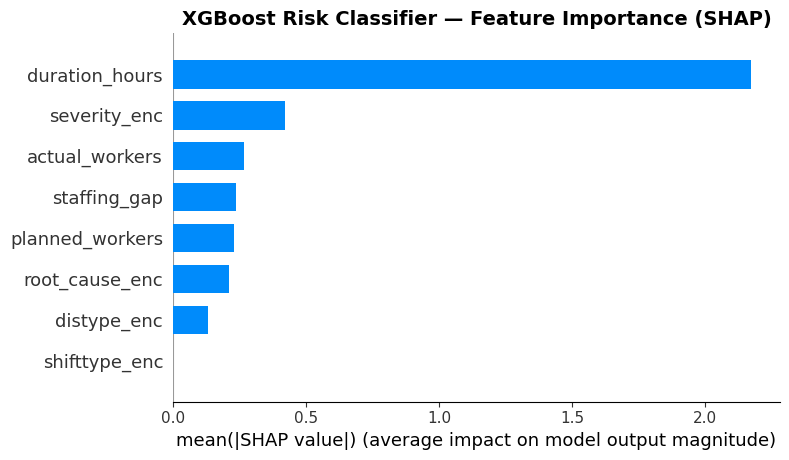

✅ Risk classifier bar plot saved!


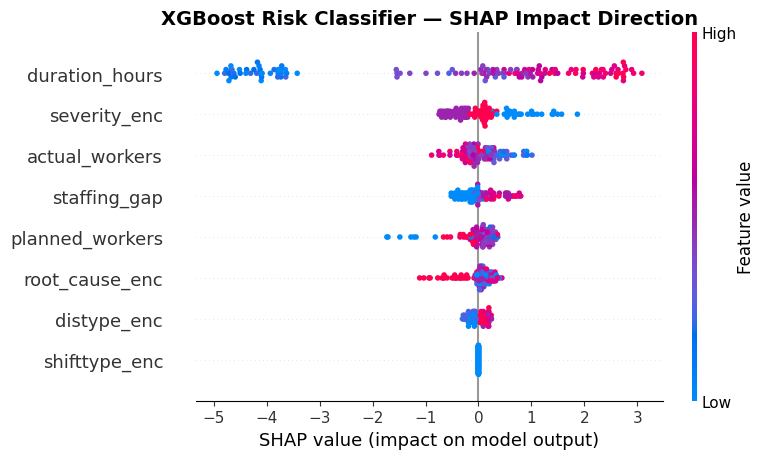

✅ Risk classifier dot plot saved!

🔄 Generating SHAP values for Throughput model...


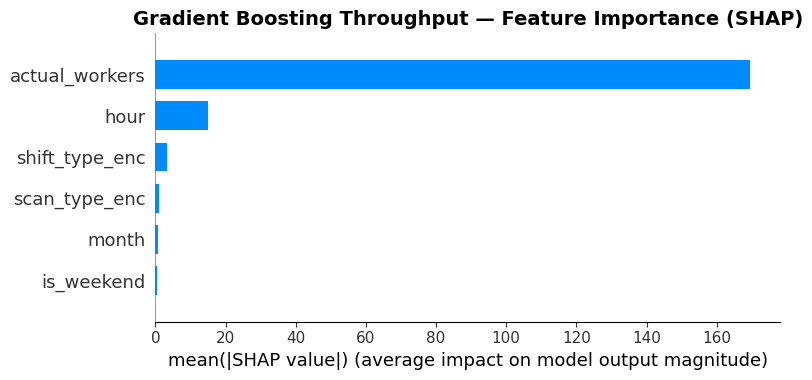

✅ Throughput bar plot saved!


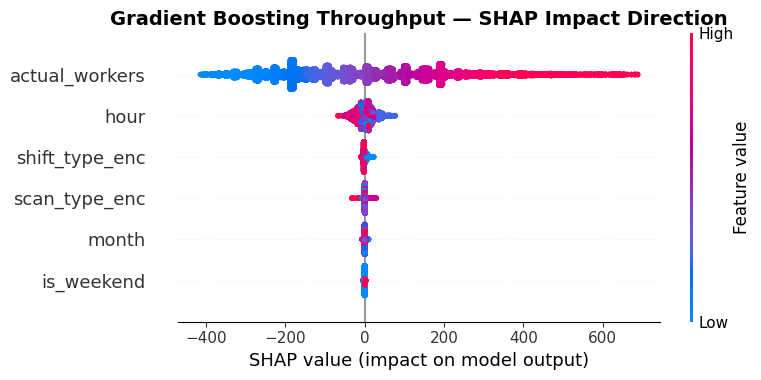

✅ Throughput dot plot saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All 4 SHAP plots downloaded!


In [7]:
# ═══════════════════════════════════════════════════════════════════
# SHAP EXPLAINABILITY PLOTS
# ═══════════════════════════════════════════════════════════════════

# ── PART 1: XGBoost Risk Classifier SHAP ─────────────────────────
print("🔄 Generating SHAP values for Risk Classifier...")

explainer_risk = shap.TreeExplainer(xgb_model)
shap_values_risk = explainer_risk.shap_values(X_risk)

# Plot 1: Summary bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_risk, X_risk,
                  feature_names=risk_features,
                  plot_type="bar",
                  show=False)
plt.title("XGBoost Risk Classifier — Feature Importance (SHAP)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_risk_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk classifier bar plot saved!")

# Plot 2: Summary dot plot (shows direction of impact)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_risk, X_risk,
                  feature_names=risk_features,
                  show=False)
plt.title("XGBoost Risk Classifier — SHAP Impact Direction",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_risk_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Risk classifier dot plot saved!")

# ── PART 2: Gradient Boosting Throughput SHAP ────────────────────
print("\n🔄 Generating SHAP values for Throughput model...")

explainer_gb = shap.TreeExplainer(gb_model)
shap_values_gb = explainer_gb.shap_values(X_throughput)

# Plot 3: Summary bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gb, X_throughput,
                  feature_names=throughput_features,
                  plot_type="bar",
                  show=False)
plt.title("Gradient Boosting Throughput — Feature Importance (SHAP)",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_throughput_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Throughput bar plot saved!")

# Plot 4: Summary dot plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_gb, X_throughput,
                  feature_names=throughput_features,
                  show=False)
plt.title("Gradient Boosting Throughput — SHAP Impact Direction",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_throughput_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Throughput dot plot saved!")

# ── Download all 4 plots ──────────────────────────────────────────
from google.colab import files
files.download('shap_risk_bar.png')
files.download('shap_risk_dot.png')
files.download('shap_throughput_bar.png')
files.download('shap_throughput_dot.png')

print("\n🎉 All 4 SHAP plots downloaded!")

In [8]:
from google.colab import files
files.download('shap_throughput_bar.png')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>